# E-Commerce Olist Analytics

## Exploratory Data Analysis

## Load the datasets

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_customers_cleaned_dataset.parquet")
orders = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_orders_cleaned_dataset.parquet")
order_items = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_order_items_cleaned_dataset.parquet")
payments = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_order_payments_cleaned_dataset.parquet")
reviews = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_order_reviews_cleaned_dataset.parquet")
products = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_products_cleaned_dataset.parquet")
sellers = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_sellers_cleaned_dataset.parquet")
geolocation = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/olist_geolocation_cleaned_dataset.parquet")
category_translation = pd.read_parquet("C:/Users/ASHOK/Desktop/Data Analyst/Projects/E-Commerece Olist Project/E-Commerce Olist Cleaned Dataset Parquet/category_translation_cleaned_dataset.parquet")

In [3]:
category_products = products[
    products["product_category_name"].notna()
]

## Sales Analysis

### What is the total revenue?

In [4]:
total_revenue= order_items['price'].sum()
print(f'Total Revenue: R$ {total_revenue:,.2f}')

Total Revenue: R$ 13,591,643.70


The platform generated R$ 13,591,643.70 in product sales. This metric represents revenue from products only and excludes shipping charges.

### How many unique orders were placed during the analysis period?

In [5]:
total_orders= orders['order_id'].nunique()
print(f'Total Orders: {total_orders}')

Total Orders: 99441


There are total 99441 unique business orders were placed during the analysis period.

### What is the average order value?

In [6]:
average_order_value = total_revenue / total_orders
print(f'Average Order Value: R$ {average_order_value:.2f}')

Average Order Value: R$ 136.68


On average, customers spend R$ 136.68 per order. This metric can help evaluate customer purchasing behavior and measure the effectiveness of pricing and promotional strategies.

### How did monthly sales revenue changed over time?

In [7]:
#Merge orders and order_items
sales= pd.merge(orders, order_items, on='order_id', how='inner')

#Extract Month
sales['order_month']= sales['order_purchase_timestamp'].dt.to_period('M')

#Monthly revenue
monthly_revenue= sales.groupby('order_month')['price'].sum().reset_index()
monthly_revenue['order_month']= monthly_revenue['order_month'].astype(str)
monthly_revenue.head()

,order_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


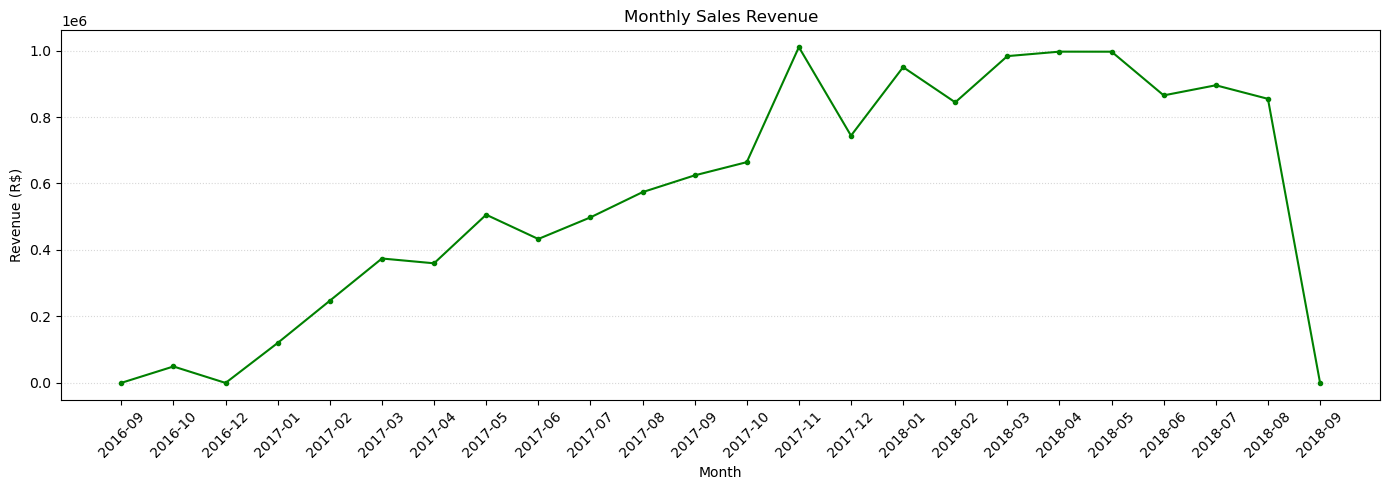

In [8]:
#Visualization
plt.figure(figsize=(14,5))

plt.plot(monthly_revenue['order_month'], monthly_revenue['price'], color='green', linestyle='-', marker='o', markersize=3)

plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Key Findings: Revenue showed an overall upward/downward trend over the analysis period. Revenue fluctutation may indicate seasonal demand or the impact of promotional campaigns.

Monthly revenue analysis highlights how sales performance changed throughout the analysis period. Identifying months with significant revenue growth or decline helps the business understand seasonality, evaluate promotional campaigns, and improve demand forecasting for future planning.

### How did the number of customer orders change each month?

In [9]:
monthly_orders= sales.groupby('order_month')['order_id'].nunique().reset_index(name='total_orders')
monthly_orders['order_month']= monthly_orders['order_month'].astype(str)
monthly_orders.head()

,order_month,total_orders
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733


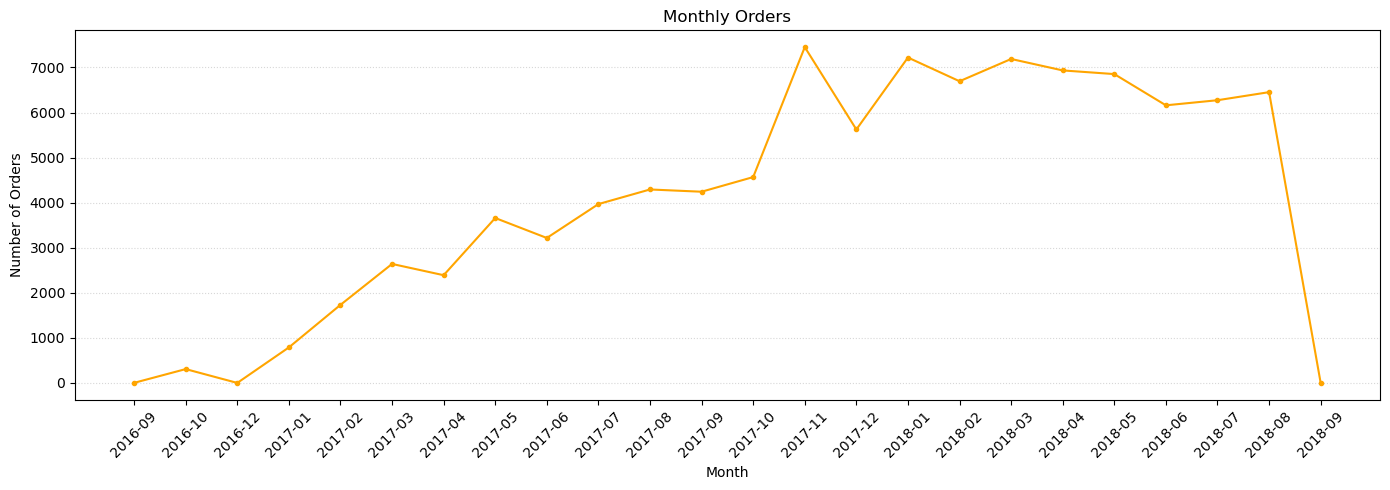

In [10]:
#Visualization
plt.figure(figsize=(14,5))

plt.plot(monthly_orders['order_month'], monthly_orders['total_orders'], color='orange', linestyle='-', marker='o', markersize=3)

plt.title('Monthly Orders')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Monthly order trends provide insight into changes in customer demand over time. Peaks in order volume may indicate successful promotional activities or seasonal shopping periods, while lower volumes may highlight opportunities for targeted marketing and customer engagement strategies.

### Which months generated the highest and lowest sales revenue?

In [11]:
highest_revenue_month= monthly_revenue.loc[monthly_revenue['price'].idxmax()]
lowest_revenue_month= monthly_revenue.loc[monthly_revenue['price'].idxmin()]

print('Highest Revenue Month')
print(highest_revenue_month)

print()

print('Lowest Revenue Month')
print(lowest_revenue_month)

Highest Revenue Month
order_month       2017-11
price          1010271.37
Name: 13, dtype: object

Lowest Revenue Month
order_month    2016-12
price             10.9
Name: 2, dtype: object


Kye Findings: The highest revenue was recorded in 2017-11, while the lowest occurred in 2016-12.

Comparing the highest and lowest revenue months helps identify seasonal demand patterns and periods requiring business attention. Understanding these variations supports inventory planning, marketing campaign scheduling, and resource allocation to maximize revenue throughout the year.

### Which months recorded the highest and lowest number of customer orders

In [12]:
highest_orders= monthly_orders.loc[monthly_orders['total_orders'].idxmax()]
lowest_orders= monthly_orders.loc[monthly_orders['total_orders'].idxmin()]

print('Highest  Orders')
print(highest_orders)

print()

print('Lowest  Orders')
print(lowest_orders)

Highest  Orders
order_month     2017-11
total_orders       7451
Name: 13, dtype: object

Lowest  Orders
order_month     2016-12
total_orders          1
Name: 2, dtype: object


The highest orders was recorded in 2017-11, while the lowest occurred in 2016-12.

Identifying months with the highest and lowest order volumes enables the business to recognize seasonal purchasing behavior and evaluate operational performance. These insights support workforce planning, inventory management, and promotional strategies to maintain consistent customer demand throughout the year.

## Customer Analysis

### How many unique customers made purchases during the analysis period?

In [13]:
total_customers= customers['customer_unique_id'].nunique()
print(f'Total Unique Customers: {total_customers:,}')

Total Unique Customers: 96,096


The platform served 96,096 unique customers during the analysis period. Measuring unique customers provides a clearer view of the active customers.

### How many customers are repeat customers?

In [14]:
customer_orders = pd.merge(customers,orders, on="customer_id").groupby("customer_unique_id")["order_id"].count().reset_index(name="total_orders")

repeat_customers= customer_orders[customer_orders['total_orders']>1]

repeat_customer_count= repeat_customers.shape[0]

repeat_percentage= (repeat_customer_count/customer_orders.shape[0])*100

print(f'Repeat Customers: {repeat_customer_count:,}')

print(f'Repeat Customer Rate: {repeat_percentage:.2f}%')

Repeat Customers: 2,997
Repeat Customer Rate: 3.12%


Repeat customers represent users who completed more than one purchase during the analysis period. A higher repeat customer rate indicates stronger customer loyalty and satisfaction, while a lower rate may suggest opportunities to improve retention through loyalty programs, personalized marketing, and enhanced customer experience.

### Which states have the highest number of customers?

In [15]:
state_customers= customers.groupby('customer_state')['customer_unique_id'].nunique().reset_index(name='total_customers').sort_values('total_customers', ascending=False)
state_customers.head()

,customer_state,total_customers
25,SP,40302
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882


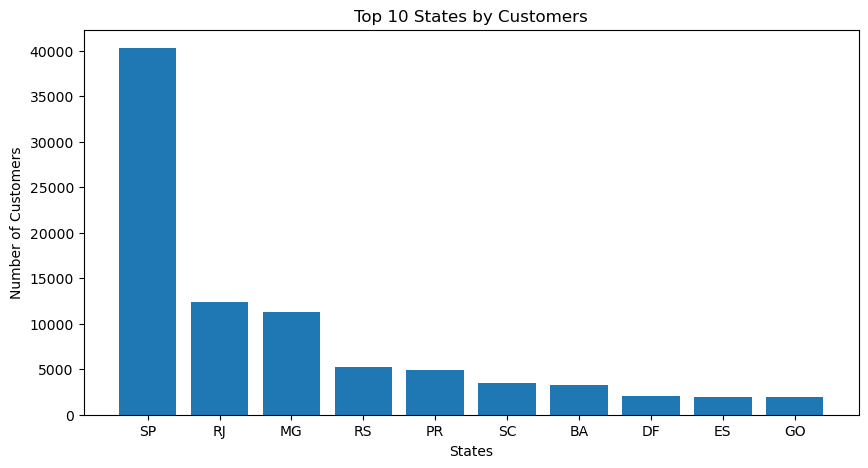

In [16]:
#Visualization
top_10_states= state_customers.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_10_states['customer_state'], top_10_states['total_customers'])

plt.title('Top 10 States by Customers')
plt.xlabel('States')
plt.ylabel('Number of Customers')

plt.show()

Customer distribution across states reveals the company's strongest geographic markets. States with a high concentration of customers may represent mature markets, while states with lower customer counts may offer opportunities for future expansion through targeted marketing and regional business strategies.

### Which cities have the highest number of customers?

In [17]:
city_customers= customers.groupby('customer_city')['customer_unique_id'].nunique().reset_index(name='total_customers').sort_values('total_customers', ascending=False)
city_customers.head()

,customer_city,total_customers
3597,sao paulo,14984
3155,rio de janeiro,6620
453,belo horizonte,2672
558,brasilia,2069
1143,curitiba,1465


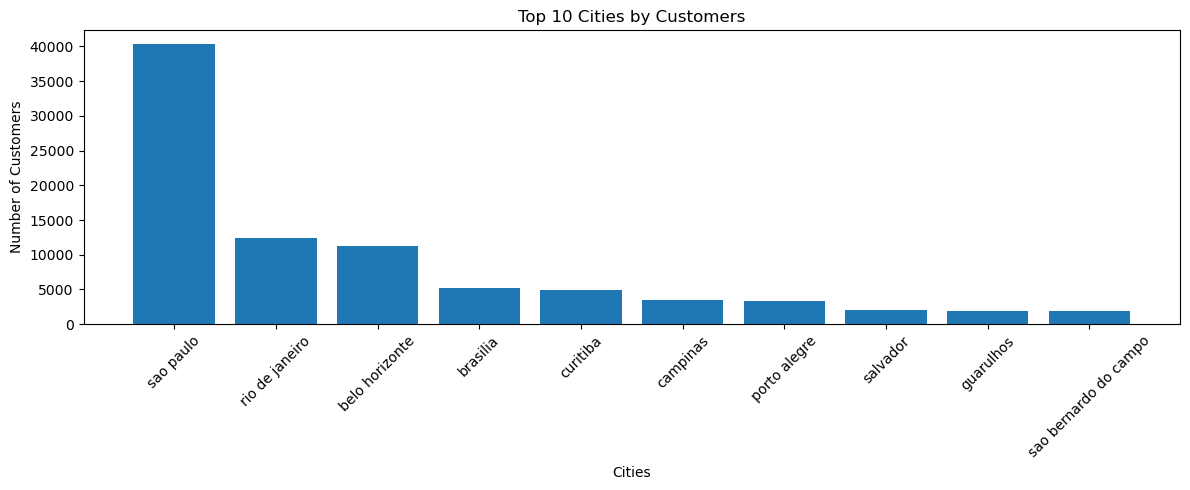

In [18]:
#Visualization
top_10_cities= city_customers.head(10)

plt.figure(figsize=(12,5))

plt.bar(top_10_cities['customer_city'], top_10_states['total_customers'])

plt.title('Top 10 Cities by Customers')
plt.xlabel('Cities')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Identifying cities with the largest customer populations helps the business prioritize regional operations, logistics, and marketing campaigns. Concentrating resources in high-demand cities can improve customer service while supporting continued business growth.

### What is the distribution of customers by state?

In [19]:
state_distribution= customers['customer_state'].value_counts()
state_distribution.head()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

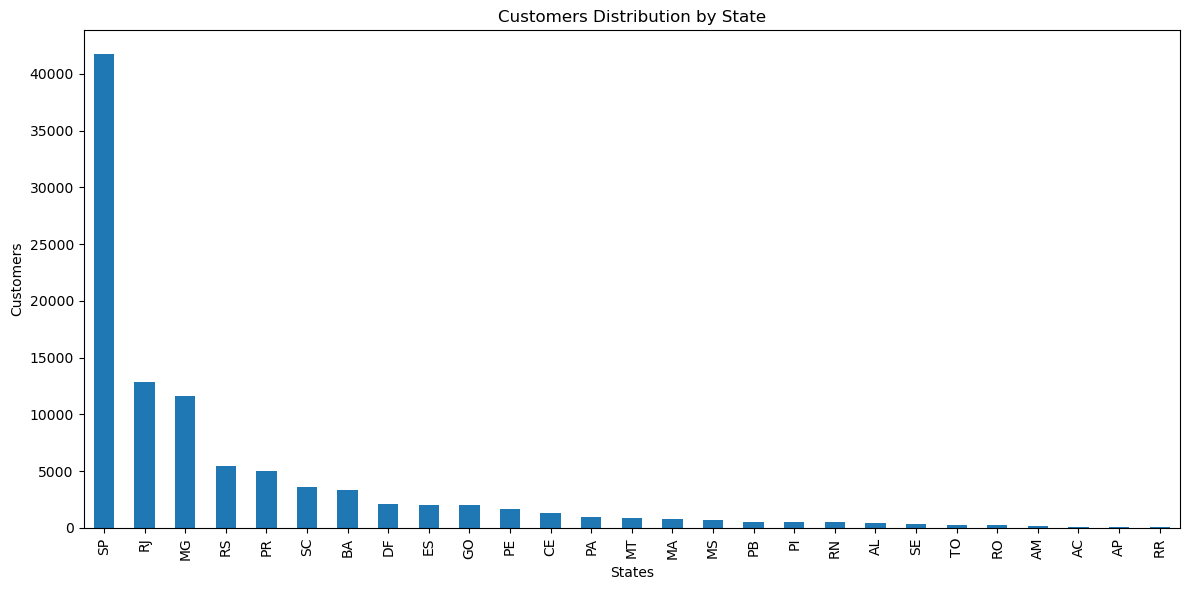

In [20]:
#Visualization
#Visualization
plt.figure(figsize=(12,6))

state_distribution.plot(kind='bar')

plt.title('Customers Distribution by State')
plt.xlabel('States')
plt.ylabel('Customers')
plt.tight_layout()

plt.show()

Examining the complete distribution of customers across states highlights geographic concentration and market penetration. This analysis supports regional expansion planning, resource allocation, and demand forecasting.

### Which states generate the highest revenue?

In [21]:
customer_sales= (pd.merge(customers, orders, on='customer_id').merge(order_items, on='order_id'))

state_revenue= customer_sales.groupby('customer_state')['price'].sum().reset_index(name='total_revenue').sort_values('total_revenue', ascending=False)
state_revenue.head()

,customer_state,total_revenue
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76


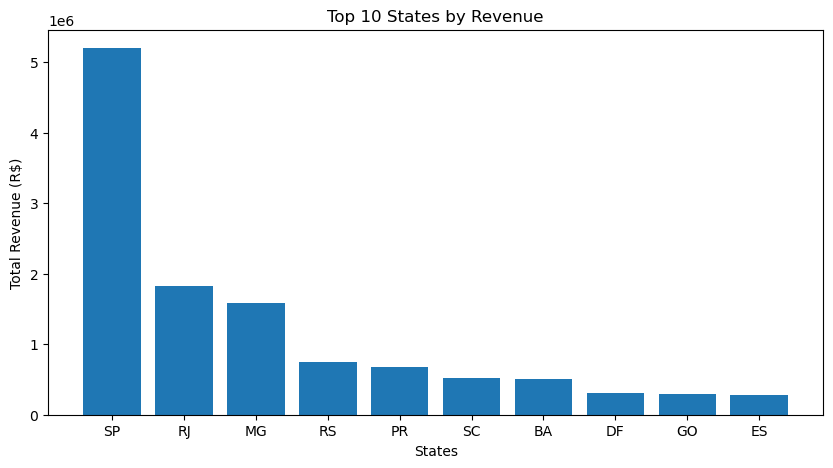

In [22]:
#Visualization
top_10_states_revenue= state_revenue.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_10_states_revenue['customer_state'], top_10_states_revenue['total_revenue'])

plt.title('Top 10 States by Revenue')
plt.xlabel('States')
plt.ylabel('Total Revenue (R$)')

plt.show()

Revenue by state identifies the company's most valuable regional markets. Comparing customer counts with revenue helps determine whether high-performing states generate value through a large customer base, higher average spending, or both. These insights support regional investment and growth strategies.

## Product Performance Analysis

### Which product categories generate the highest revenue?

In [23]:
category_sales= pd.merge(order_items, category_products, on='product_id').merge(category_translation, on='product_category_name', how='left')

category_revenue= category_sales.groupby('product_category_name_english')['price'].sum().reset_index(name='total_revenue').sort_values('total_revenue', ascending=False)
category_revenue.head()

,product_category_name_english,total_revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32


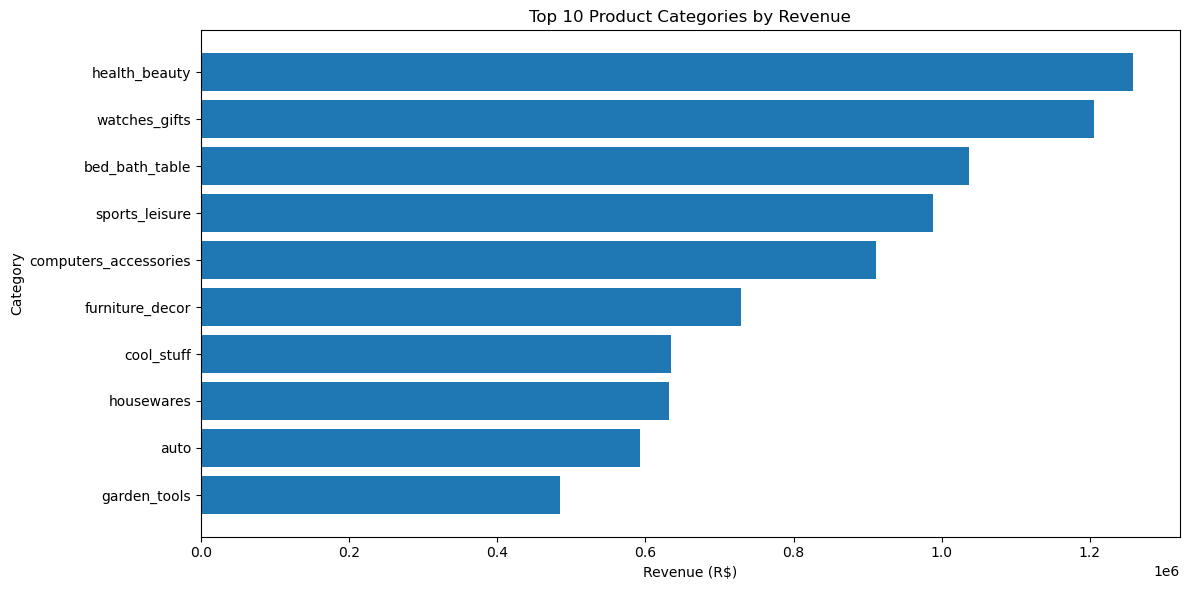

In [24]:
#Visualization
top_10_category_revenue= category_revenue.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_10_category_revenue['product_category_name_english'], top_10_category_revenue['total_revenue'])

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('Category')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Business Insight: Product category revenue analysis identifies the categories that contribute the most to overall sales. These high-performing categories represent the company's primary revenue drivers and should be prioritized for inventory management, marketing campaigns, and promotional investments.

### Which product categories sell the highest number of products?

In [25]:
category_quantity= category_sales.groupby('product_category_name_english')['order_id'].count().reset_index(name='products_sold').sort_values('products_sold', ascending=False)
category_quantity.head()

,product_category_name_english,products_sold
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827


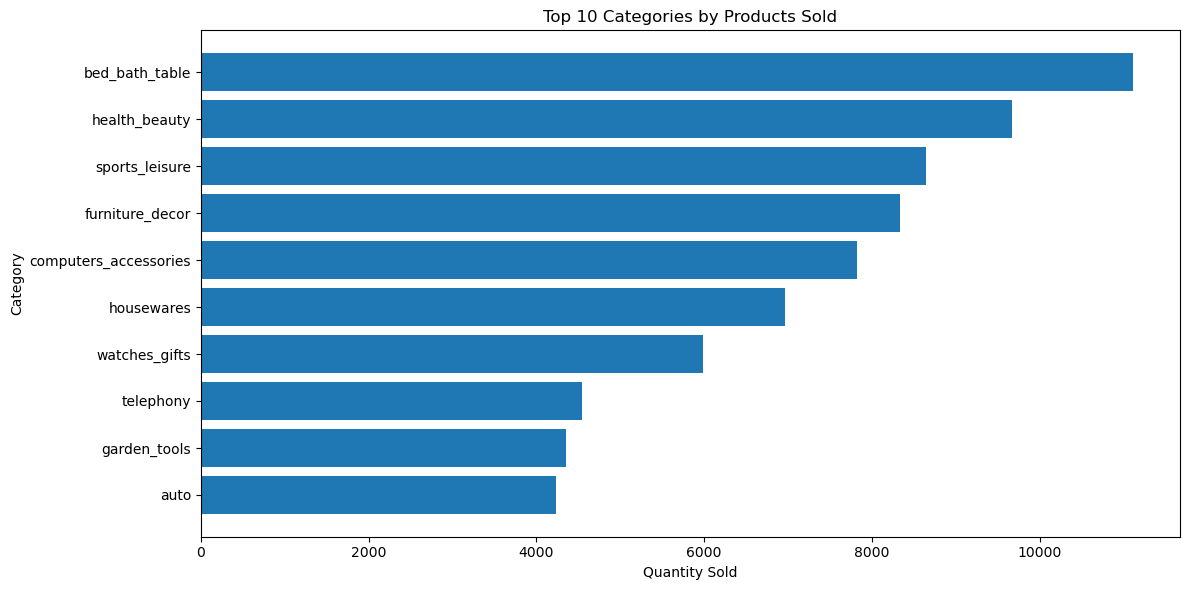

In [26]:
#Visualization
top_10_category_quantity= category_quantity.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_10_category_quantity['product_category_name_english'], top_10_category_quantity['products_sold'])

plt.title('Top 10 Categories by Products Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Business Insight: Sales volume analysis highlights product categories with the highest customer demand. Comparing sales volume with revenue helps distinguish between categories that succeed through high demand versus those that generate revenue from higher-priced products.

### Which product categories have the highest average selling price?

In [27]:
average_category_price= category_sales.groupby('product_category_name_english')['price'].mean().reset_index(name='average_price').sort_values('average_price', ascending=False)
average_category_price.head()

,product_category_name_english,average_price
14,computers,1098.340542
64,small_appliances_home_oven_and_coffee,624.285658
45,home_appliances_2,476.124958
0,agro_industry_and_commerce,342.124858
56,musical_instruments,281.616000


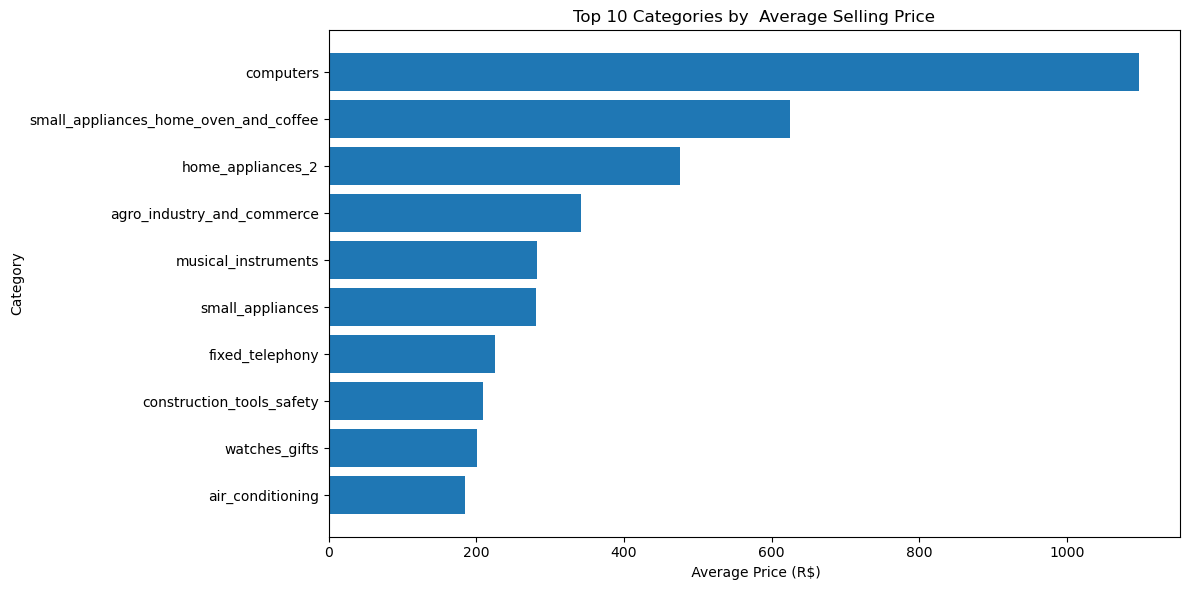

In [28]:
#Visualization
top10_average_category_price= average_category_price.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10_average_category_price['product_category_name_english'], top10_average_category_price['average_price'])

plt.title('Top 10 Categories by  Average Selling Price')
plt.xlabel(' Average Price (R$)')
plt.ylabel('Category')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Business Insight: Average selling price identifies premium product categories that generate higher revenue per transaction. These categories may require different pricing, marketing, and inventory strategies compared with high-volume, lower-priced categories.

### Which are the top 10 best-selling products?

In [29]:
top_products= order_items.groupby('product_id')['order_id'].count().reset_index(name='units_sold').sort_values('units_sold', ascending=False)
top_products.head(10)

,product_id,units_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,488
8613,422879e10f46682990de24d770e7f83d,484
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,388
10840,53759a2ecddad2bb87a079a1f1519f73,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,281
8051,3dd2a17168ec895c781a9191c1e95ad7,274


Business Insight: Best-selling products represent items with consistently high customer demand. These products should receive priority for inventory replenishment and stock availability to reduce the risk of lost sales.

### Which products generate the highest revenue?

In [30]:
top_product_revenue= order_items.groupby('product_id')['price'].sum().reset_index(name='total_revenue').sort_values('total_revenue', ascending=False)
top_product_revenue.head(10)

,product_id,total_revenue
24086,bb50f2e236e5eea0100680137654686c,63885.00
14068,6cdd53843498f92890544667809f1595,54730.20
27613,d6160fb7873f184099d9bc95e30376af,48899.34
27039,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
19742,99a4788cb24856965c36a24e339b6058,43025.56
8051,3dd2a17168ec895c781a9191c1e95ad7,41082.60
4996,25c38557cf793876c5abdd5931f922db,38907.32
12351,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
10867,53b36df67ebb7c41585e8d54d6772e08,37683.42
22112,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


Business Insight: Revenue by product identifies the company's most financially valuable products. Comparing revenue with sales volume helps distinguish products that generate revenue through premium pricing versus high sales frequency.

### How are product prices distributed?

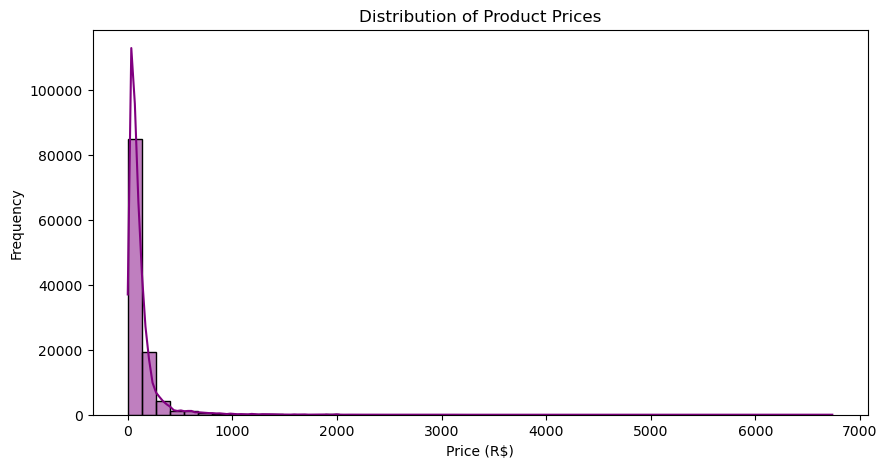

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(order_items['price'], bins=50, kde=True, color='purple', edgecolor='black')

plt.title('Distribution of Product Prices')
plt.xlabel('Price (R$)')
plt.ylabel('Frequency')

plt.show()

Business Insight: Price distribution provides insight into the company's pricing strategy and product portfolio. Understanding the concentration of products across different price ranges helps evaluate customer affordability and market positioning.

### Is there a relationship between product price and customer review score?

In [32]:
price_review= pd.merge(order_items, reviews, on='order_id')

price_review_analysis= price_review.groupby('review_score')['price'].mean().reset_index()
price_review_analysis

,review_score,price
0,1,127.350068
1,2,115.849138
2,3,110.059704
3,4,118.602628
4,5,121.219825


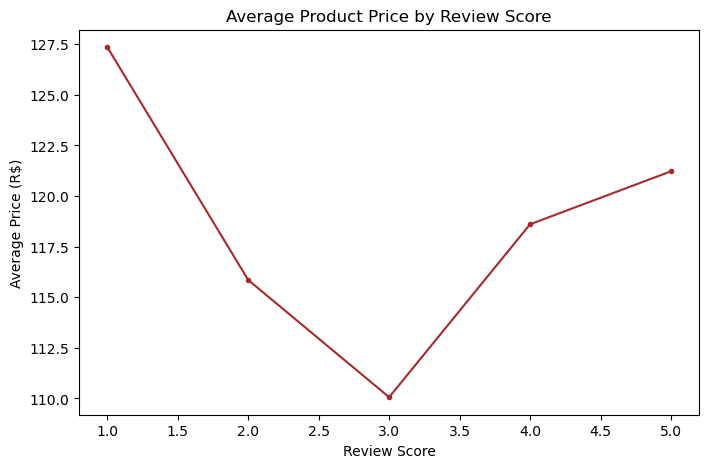

In [33]:
#Visualization
plt.figure(figsize=(8,5))

plt.plot(price_review_analysis['review_score'], price_review_analysis['price'], color='brown', linestyle='-', marker='o', markersize=3)

plt.title('Average Product Price by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Price (R$)')

plt.show()

Business Insight: Comparing average product price across review scores helps determine whether premium-priced products receive higher customer satisfaction. If expensive products receive lower ratings, it may indicate unmet customer expectations and opportunities to improve product quality or customer experience.

## Seller Performance Analysis

### How many sellers are registered on the platform?

In [34]:
total_sellers= sellers['seller_id'].nunique()
print(f'Total Sellers: {total_sellers:,}')

Total Sellers: 3,095


Business Insight: The marketplace consists of 3,095 unique sellers. Understanding the size of the seller network provides insight into marketplace diversity and supply capacity. A larger seller base generally increases product variety and customer choice.

### Which sellers generated the highest revenue?

In [35]:
seller_sales= order_items.groupby('seller_id')['price'].sum().reset_index(name='total_revenue').sort_values('total_revenue', ascending=False)
seller_sales.head()

,seller_id,total_revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1013,53243585a1d6dc2643021fd1853d8905,222776.05
881,4a3ca9315b744ce9f8e9374361493884,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89


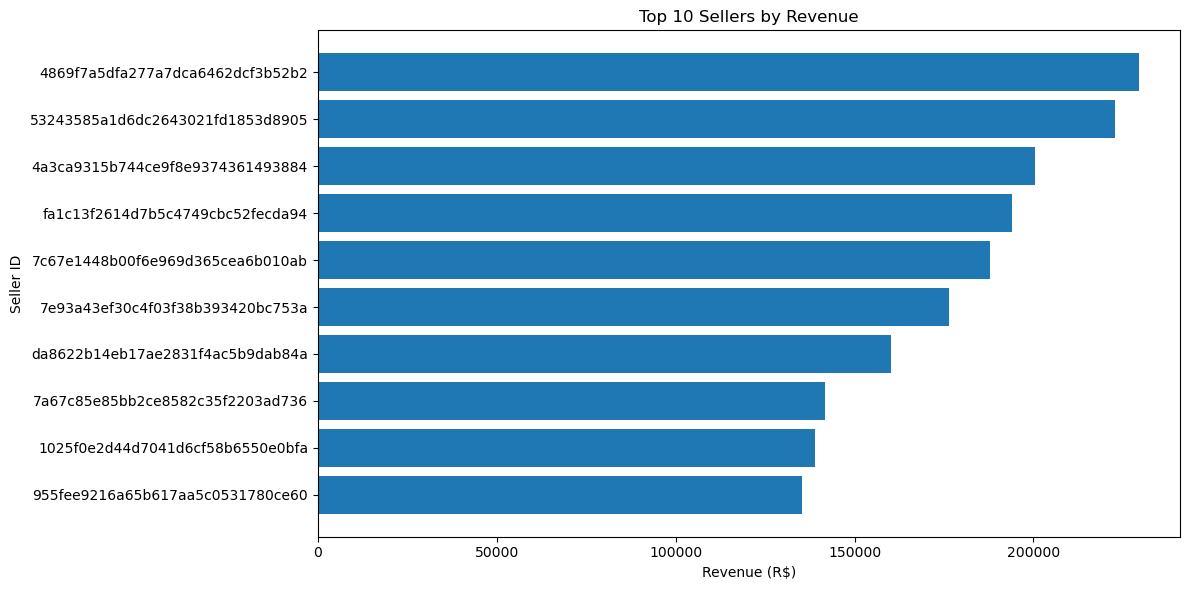

In [36]:
#Visualization
top10_seller_sales= seller_sales.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10_seller_sales['seller_id'], top10_seller_sales['total_revenue'])

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Revenue (R$)')
plt.ylabel('Seller ID')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Business Insight: Revenue generated by individual sellers highlights the marketplace's most valuable business partners. Identifying high-performing sellers helps prioritize seller engagement, promotional opportunities, and strategic partnerships.

### Which sellers fulfilled the highest number of orders?

In [37]:
seller_orders= order_items.groupby('seller_id')['order_id'].nunique().reset_index(name='total_orders').sort_values('total_orders', ascending=False)
seller_orders.head()

,seller_id,total_orders
1235,6560211a19b47992c3666cc44a7e94c0,1854
881,4a3ca9315b744ce9f8e9374361493884,1806
2481,cc419e0650a3c5ba77189a1882b7556a,1706
368,1f50f920176fa81dab994f9023523100,1404
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314


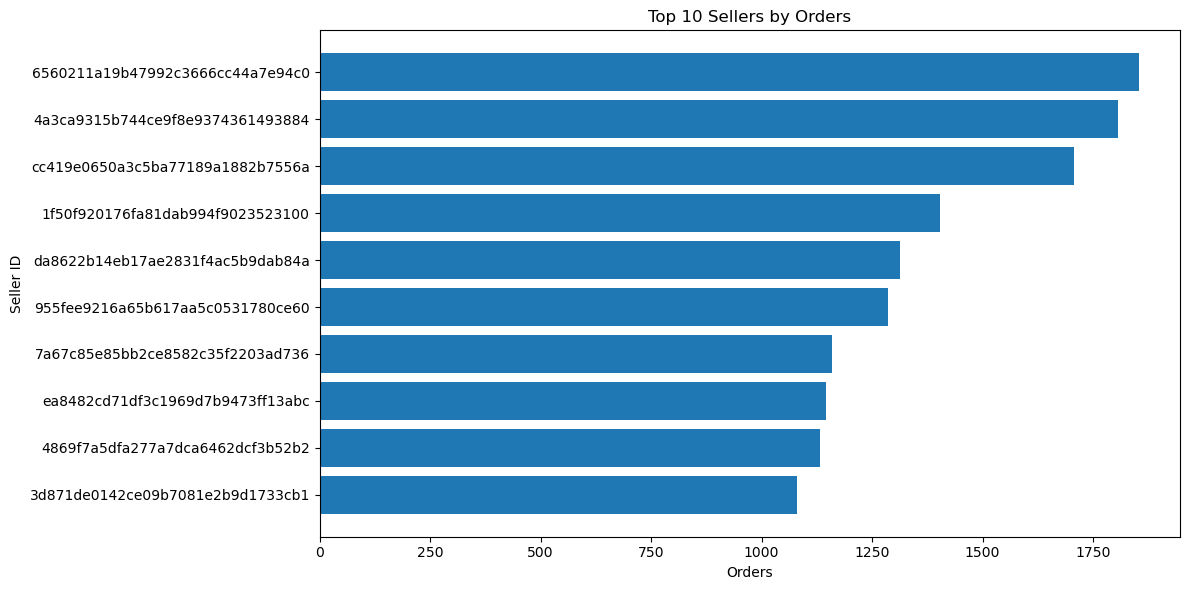

In [38]:
#Visualization
top10_seller_orders= seller_orders.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10_seller_orders['seller_id'], top10_seller_orders['total_orders'])

plt.title('Top 10 Sellers by Orders')
plt.xlabel('Orders')
plt.ylabel('Seller ID')

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

Business Insight: Sellers with the highest order volumes demonstrate strong customer demand and operational capacity. Comparing order volume with revenue can reveal whether sellers succeed through premium pricing or high sales frequency.

### Which states have the highest number of sellers?

In [39]:
seller_states= sellers.groupby('seller_state')['seller_id'].nunique().reset_index(name='total_sellers').sort_values('total_sellers', ascending=False)
seller_states.head()

,seller_state,total_sellers
22,SP,1849
15,PR,349
8,MG,244
20,SC,190
16,RJ,171


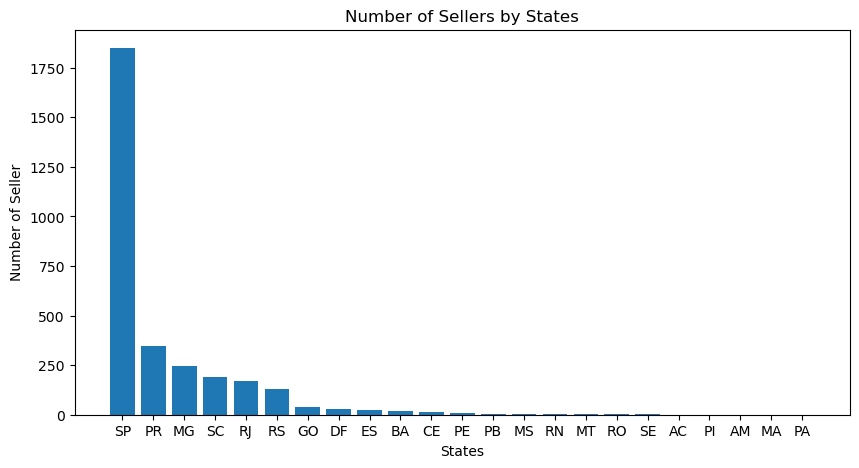

In [40]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(seller_states['seller_state'], seller_states['total_sellers'])

plt.title('Number of Sellers by States')
plt.xlabel('States')
plt.ylabel('Number of Seller')

plt.show()

Business Insight: Seller distribution across states reveals where marketplace supply is concentrated. Regions with many sellers may offer faster delivery and greater product availability, while regions with fewer sellers may represent expansion opportunities.

### Which seller states generated the highest revenue?

In [41]:
seller_revenue= pd.merge(sellers, order_items, on='seller_id')

state_revenue= seller_revenue.groupby('seller_state')['price'].sum().reset_index(name='total_revenue').sort_values('total_revenue', ascending=False)
state_revenue.head()

,seller_state,total_revenue
22,SP,8753396.21
15,PR,1261887.21
8,MG,1011564.74
16,RJ,843984.22
20,SC,632426.07


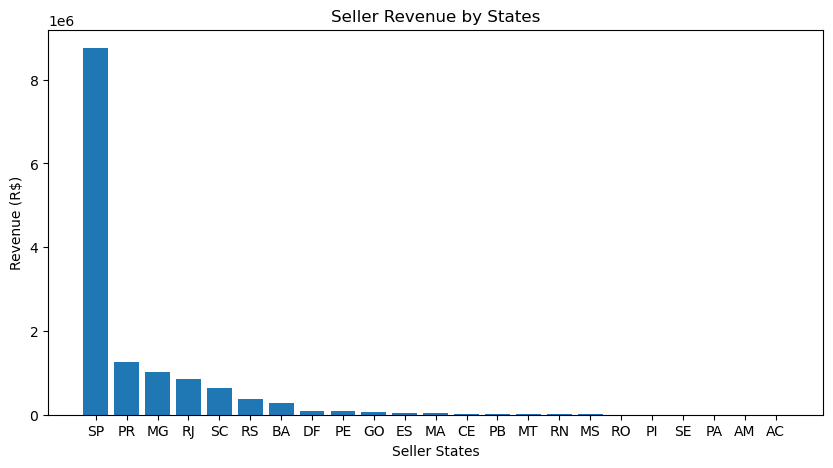

In [42]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(state_revenue['seller_state'], state_revenue['total_revenue'])

plt.title('Seller Revenue by States')
plt.xlabel('Seller States')
plt.ylabel('Revenue (R$)')

plt.show()

Business Insight: Revenue by seller state identifies the regions contributing most to marketplace sales. This analysis supports regional seller development strategies and helps identify locations with strong commercial activity.

### What is the average revenue generated per seller?

In [43]:
avg_revenue= seller_sales['total_revenue'].mean()
print(f'Average Revenue per Seller: R$ {avg_revenue:,.2f}')

Average Revenue per Seller: R$ 4,391.48


Business Insight: Average seller revenue provides a benchmark for evaluating seller performance across the marketplace. Comparing individual seller revenue with the overall average helps identify high-performing sellers and those who may benefit from additional support or business development initiatives.

### Is marketplace revenue concentrated among a small number of sellers?

In [44]:
seller_sales_sorted= seller_sales.sort_values('total_revenue',ascending=False).copy()

seller_sales_sorted['cumulative_revenue']=(seller_sales_sorted['total_revenue'].cumsum())

total_revenue= seller_sales_sorted['total_revenue'].sum()

seller_sales_sorted['cumulative_percentage']= (seller_sales_sorted['cumulative_revenue']/total_revenue)*100
seller_sales_sorted.head(20)

,seller_id,total_revenue,cumulative_revenue,cumulative_percentage
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,229472.63,1.688336
1013,53243585a1d6dc2643021fd1853d8905,222776.05,452248.68,3.327402
881,4a3ca9315b744ce9f8e9374361493884,200472.92,652721.60,4.802374
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,846763.63,6.230031
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1034687.52,7.612674
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,1211119.39,8.910765
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1371355.96,10.089699
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1513101.49,11.132586
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1652070.04,12.155042
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1787241.74,13.149563


In [45]:
top10_percent= int(len(seller_sales_sorted)*0.10)

revenue_share= (seller_sales_sorted.head(top10_percent)['total_revenue'].sum())

share_percentage= (revenue_share/total_revenue)*100

print(f'Top 10% sellers generate {share_percentage:.2f}% of total revenue.')

Top 10% sellers generate 67.49% of total revenue.


Business Insight: Revenue concentration analysis evaluates whether the marketplace depends heavily on a small group of sellers. If a small percentage of sellers contributes a large share of revenue, the business faces concentration risk and should consider strategies to strengthen the performance of smaller sellers while maintaining relationships with top performers.

## Delivery & Logistic Analysis

In [47]:
#Logistic Dataframe
logistics= pd.merge(orders, customers, on='customer_id').merge(order_items, on='order_id')
logistics.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


### What is the average delivery time for completed orders?

In [52]:
delivered_orders= logistics[(logistics['order_status']== 'delivered')].copy()

delivered_orders['delivery_days']= (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days

average_delivery= delivered_orders['delivery_days'].mean()

print(f'Average Delivery Time: {average_delivery:.2f} days')

Average Delivery Time: 12.01 days


Business Insight: The average delivery time measures operational efficiency from purchase to customer delivery. Reducing delivery time improves customer experience, increases satisfaction, and strengthens customer loyalty.

### What is the average shipping time after the seller dispatches an order?

In [55]:
delivered_orders['shipping_days']= (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_delivered_carrier_date']).dt.days

average_shipping= delivered_orders['shipping_days'].mean()

print(f'Average Shipping Time: {average_shipping:.2f} days')

Average Shipping Time: 8.73 days


Business Insight: Shipping time reflects carrier performance after dispatch. Monitoring this metric helps identify opportunities to optimize logistics operations and improve delivery efficiency.

### What percentage of orders were delivered on time versus late?

In [61]:
delivered_orders['delivery_status']= np.where(delivered_orders['order_delivered_customer_date']<= delivered_orders['order_estimated_delivery_date'],
    'On Time', 'Late')

delivery_status= delivered_orders['delivery_status'].value_counts()

delivery_percentage= delivered_orders['delivery_status'].value_counts(normalize=True) * 100

print(delivery_status)
print()
print(delivery_percentage)

delivery_status
On Time    101475
Late         8722
Name: count, dtype: int64

delivery_status
On Time    92.085084
Late        7.914916
Name: proportion, dtype: float64


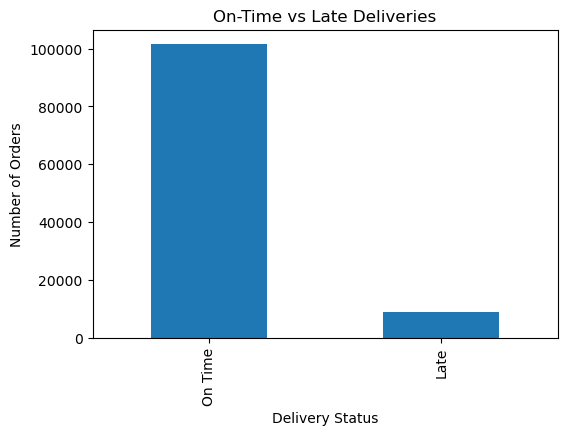

In [63]:
#Visualization
plt.figure(figsize=(6,4))

delivery_status.plot(kind='bar')

plt.title('On-Time vs Late Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.show()

Business Insight: Comparing on-time and late deliveries provides a direct measure of logistics performance. A high on-time delivery rate improves customer trust, while frequent delays may negatively affect customer satisfaction and increase operational costs.

### How many days early or late were orders delivered compared with estimated delivery date?

In [64]:
delivered_orders['delivery_difference'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days
delivered_orders['delivery_difference'].describe()

count    110189.000000
mean        -12.029041
std          10.158194
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_difference, dtype: float64

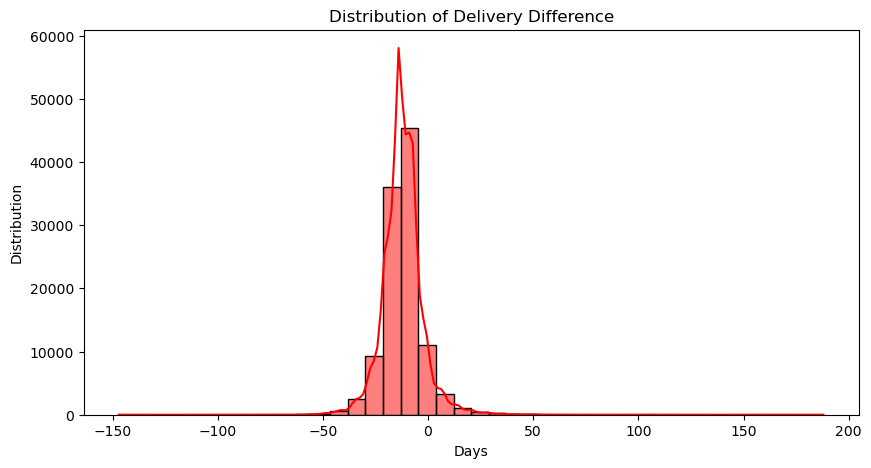

In [67]:
#Visualization
plt.figure(figsize=(10,5))

sns.histplot(delivered_orders['delivery_difference'], bins=40, kde=True, color='red', edgecolor='black')

plt.title('Distribution of Delivery Difference')
plt.xlabel('Days')
plt.ylabel('Distribution')

plt.show()

Business Insight: Delivery difference measures how accurately the company meets promised delivery dates. Frequent early deliveries may improve customer satisfaction, while consistent delays indicate operational inefficiencies requiring attention.

### Which customer states have the fastest average delivery times?

In [70]:
fastest_states= delivered_orders.groupby('customer_state')['delivery_days'].mean().reset_index().sort_values('delivery_days', ascending=True)
fastest_states.head(10)

,customer_state,delivery_days
25,SP,8.259663
17,PR,11.480793
10,MG,11.514091
6,DF,12.501486
23,SC,14.517208
18,RJ,14.688821
22,RS,14.708299
8,GO,14.948177
11,MS,15.107275
7,ES,15.192809


Business Insight: Identifying states with the fastest deliveries highlights regions where logistics operations perform efficiently. These areas can serve as benchmarks for improving delivery performance in other regions.

### Which customer states have the slowest average delivery times?

In [71]:
slowest_states= delivered_orders.groupby('customer_state')['delivery_days'].mean().reset_index().sort_values('delivery_days', ascending=False)
slowest_states.head(10)

,customer_state,delivery_days
21,RR,27.826087
3,AP,27.753086
2,AM,25.963190
1,AL,23.992974
13,PA,23.301708
9,MA,21.203750
24,SE,20.978667
5,CE,20.537167
0,AC,20.329670
14,PB,20.119454


Business Insight: States with the longest delivery times may experience logistical challenges such as greater shipping distances, limited transportation infrastructure, or lower seller concentration. These regions represent opportunities for logistics optimization.

### Does delivery time affect customer review scores?

In [74]:
delivery_reviews= pd.merge(delivered_orders, reviews, on='order_id')

delivery_review_score= delivery_reviews.groupby('review_score')['delivery_days'].mean().reset_index()
delivery_review_score

,review_score,delivery_days
0,1,19.116192
1,2,15.337838
2,3,13.579420
3,4,11.752644
4,5,10.191565


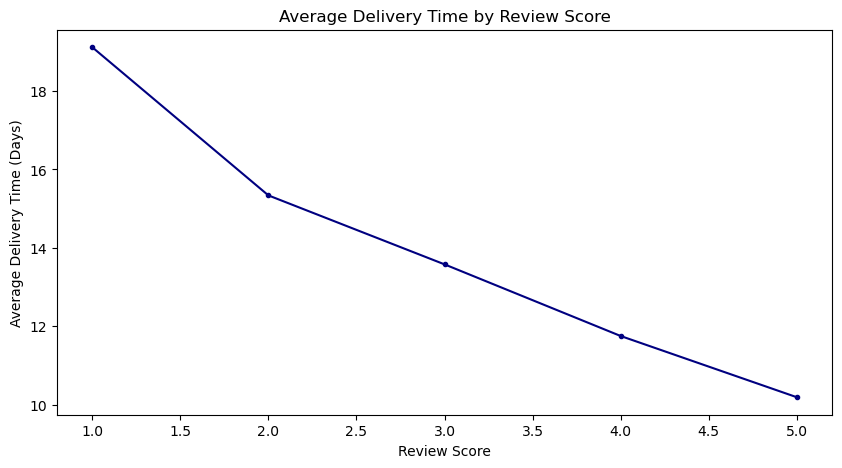

In [77]:
#Visualization
plt.figure(figsize=(10,5))

plt.plot(delivery_review_score['review_score'], delivery_review_score['delivery_days'], color='navy', marker='o', markersize=3)

plt.title('Average Delivery Time by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Time (Days)')

plt.show()

Business Insight: This analysis evaluates the relationship between operational performance and customer satisfaction. If lower review scores are associated with longer delivery times, improving logistics efficiency may directly enhance customer experience and overall ratings.

### Which sellers have the fastest average delivery time?

In [80]:
seller_delivery= delivered_orders.groupby('seller_id')['delivery_days'].mean().reset_index().sort_values('delivery_days', ascending=True)
seller_delivery.head(10)

,seller_id,delivery_days
224,139157dd4daa45c25b0807ffff348363,1.0
2826,f3511c85f59f8dec53d140501ee8e7a8,1.0
1778,96f7c797de9ca20efbe14545bed63eec,1.0
1118,5e063e85d44b0f5c3e6ec3131103a57e,1.0
1393,751e274377499a8503fd6243ad9c56f6,1.0
1215,674207551483fec113276b67b0d871ff,1.0
505,2c00c85d30361cd2ced2969cffbbffa3,1.0
1191,6561d6bf844e464b4019442692b40e02,1.0
1319,702835e4b785b67a084280efca355756,1.0
1371,734def04b237117a09321dd6d8f3f2a2,1.5


Business Insight: Sellers with consistently fast delivery performance demonstrate operational excellence and contribute positively to customer satisfaction. These sellers may serve as best-practice examples for the marketplace.

### Which sellers have the slowest average delivery time?

In [81]:
seller_delivery.tail(10)

,seller_id,delivery_days
2205,be1e9e378700cecaa4ebf71433d7915c,48.000000
1656,8c3b533c63cca56240f94f1e3a6b18ef,48.600000
1603,87f3e35268860433e13d577825aada95,51.000000
2773,eebb3372362aa9a46975164bed19a7e7,52.250000
714,3da38366e7bd9baf6369071f782ecdf0,53.000000
1584,8629a7efec1aab257e58cda559f03ba7,59.000000
929,4fb41dff7c50136976d1a5cf004a42e2,66.333333
1045,586a871d4f1221763fddb6ceefdeb95e,68.000000
1681,8e670472e453ba34a379331513d6aab1,86.000000
2597,df683dfda87bf71ac3fc63063fba369d,189.000000


Business Insight: Identifying sellers with consistently slow deliveries enables the marketplace to investigate operational bottlenecks, improve logistics support, and enhance the customer experience through targeted performance improvement initiatives.

## Customer Satisfaction & Reviews Analysis

### What is the overall average customer review score?

In [82]:
average_review= reviews['review_score'].mean()
print(f'Average Review Scores: {average_review:.2f}')

Average Review Scores: 4.09


Business Insight: The average customer review score provides a high-level measure of customer satisfaction. Monitoring this metric helps evaluate the overall shopping experience and serves as a benchmark for tracking improvements in product quality, logistics, and customer service.

### How are customer review scores distributed?

In [87]:
review_distribution= reviews['review_score'].value_counts().sort_index()
review_distribution.head()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

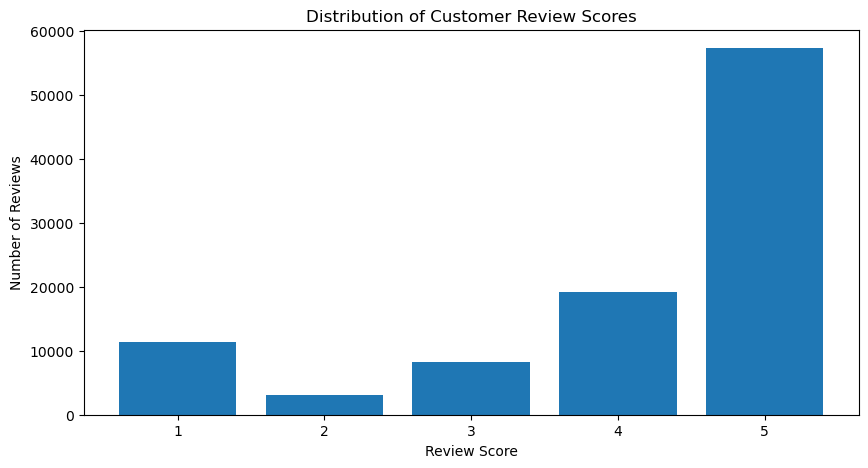

In [88]:
#Visualization
plt.figure(figsize=(10,5))

plt.bar(review_distribution.index.astype(str), review_distribution.values)

plt.title('Distribution of Customer Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.show()

Business Insight: The review score distribution shows the balance between satisfied and dissatisfied customers. A higher concentration of 4- and 5-star reviews indicates strong customer satisfaction, while a significant number of low ratings highlights opportunities for operational and service improvements.

### What percentage of customer reviews are positive, neutral and negative?

In [89]:
reviews_sentiment = reviews.copy()

reviews_sentiment['sentiment'] = np.where(reviews_sentiment['review_score'] >= 4,'Positive',
    np.where(reviews_sentiment['review_score'] == 3,'Neutral','Negative')
)

sentiment_distribution = reviews_sentiment['sentiment'].value_counts()

sentiment_percentage = reviews_sentiment['sentiment'].value_counts(normalize=True) * 100

print(sentiment_distribution)
print()
print(sentiment_percentage)

sentiment
Positive    76470
Negative    14575
Neutral      8179
Name: count, dtype: int64

sentiment
Positive    77.068048
Negative    14.688987
Neutral      8.242965
Name: proportion, dtype: float64


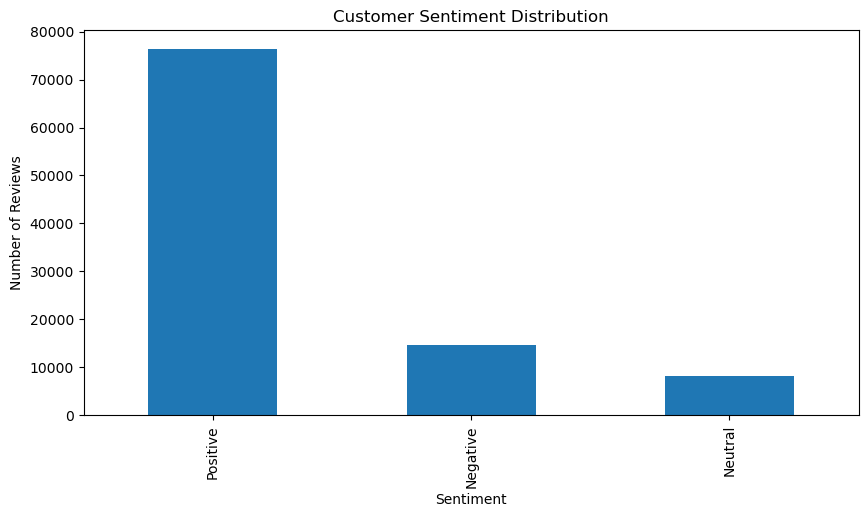

In [90]:
#Visualization
plt.figure(figsize=(10,5))

sentiment_distribution.plot( kind='bar')

plt.title('Customer Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

Business Insight: Categorizing reviews into positive, neutral, and negative sentiment provides a simplified view of customer perception. This analysis helps management monitor customer satisfaction trends and identify opportunities to improve the overall shopping experience.

### Which product categories receive the highest average customer review scores?

In [92]:
category_reviews= pd.merge(order_items, category_products, on='product_id').merge(category_translation, on='product_category_name', how='left').merge(
    reviews, on='order_id')

top_category_reviews = category_reviews.groupby('product_category_name_english')['review_score'].mean().reset_index().sort_values('review_score',ascending=False)
top_category_reviews.head(10)

,product_category_name_english,review_score
11,cds_dvds_musicals,4.642857
29,fashion_childrens_clothes,4.500000
8,books_general_interest,4.446266
22,costruction_tools_tools,4.444444
35,flowers,4.419355
9,books_imported,4.400000
10,books_technical,4.368421
37,food_drink,4.315412
53,luggage_accessories,4.315257
64,small_appliances_home_oven_and_coffee,4.302632


Business Insight: Product categories with consistently high review scores demonstrate strong customer satisfaction. These categories represent successful product offerings and can be prioritized in marketing campaigns and inventory planning.

### Which product categories receive the lowest average customer review scores?

In [93]:
top_category_reviews.tail(10)

,product_category_name_english,review_score
4,audio,3.825485
41,furniture_mattress_and_upholstery,3.815789
27,fashio_female_clothing,3.780000
58,party_supplies,3.767442
34,fixed_telephony,3.683206
30,fashion_male_clothing,3.641221
46,home_comfort_2,3.629630
57,office_furniture,3.493183
23,diapers_and_hygiene,3.256410
61,security_and_services,2.500000


Business Insight: Categories with consistently low review scores may indicate product quality issues, inaccurate product descriptions, or delivery-related problems. These categories should be investigated to improve customer satisfaction.

### Do payment methods influence customer review scores?

In [95]:
payment_reviews= pd.merge(payments, reviews, on='order_id')

payment_score= payment_reviews.groupby('payment_type')['review_score'].mean().reset_index().sort_values('review_score', ascending=False)
payment_score

,payment_type,review_score
2,debit_card,4.168084
1,credit_card,4.087637
0,boleto,4.086631
4,voucher,4.003804
3,not_defined,1.666667


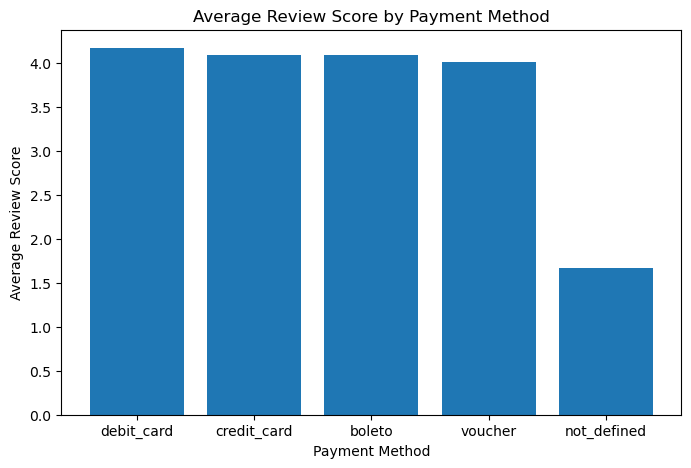

In [96]:
#Visualization
plt.figure(figsize=(8,5))

plt.bar(payment_score['payment_type'], payment_score['review_score'])

plt.title('Average Review Score by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Review Score')

plt.show()

Business Insight: Comparing review scores across payment methods helps determine whether payment experience influences customer satisfaction. Significant differences may highlight issues related to payment processing or customer expectations.

### Does delivery performance influence customer satisfaction?

In [101]:
delivery_reviews= pd.merge(delivered_orders, reviews, on='order_id')

delivery_satisfaction= delivery_reviews.groupby('delivery_status')['review_score'].mean().reset_index()
delivery_satisfaction

,delivery_status,review_score
0,Late,2.550654
1,On Time,4.210587


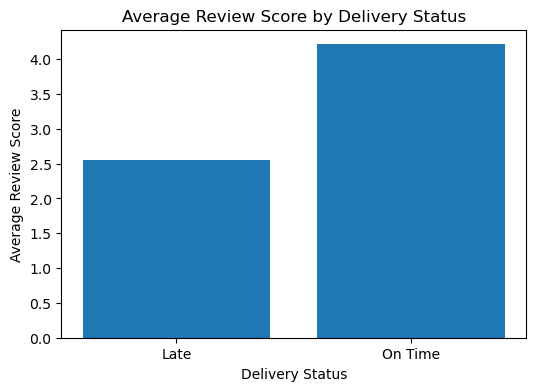

In [102]:
#Visualization
plt.figure(figsize=(6,4))

plt.bar(delivery_satisfaction['delivery_status'], delivery_satisfaction['review_score'])

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.show()

Business Insight: Comparing customer ratings for on-time and late deliveries demonstrates the impact of operational performance on customer satisfaction. If late deliveries receive lower ratings, improving delivery reliability could directly enhance customer experience and strengthen long-term customer loyalty.